# Wireless Networking and Mobile Computing

### Prerequisites

This Jupyter Notebook has been tested with Visual Studio Code, running in a local Python environment.

**Installs**

In [1]:
# --- Installs: ensure required packages are available ---
%pip install numpy pandas matplotlib --upgrade pip --quiet

Note: you may need to restart the kernel to use updated packages.


**Imports**

In [2]:
# --- Imports: libraries used in this notebook ---
import os
import subprocess
import sys
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


**Declarations**

Set the variables below and run the generation cell. 

- `scenario` is the path to the `.xml` scenario file that will be simulated.
- `thrp_file` is the name of the `.csv` file for throughput.
- `offer_file` is the name of the `.csv` file for offer.
- `delay_file` is the name of the `.csv` file for delay.

In [17]:
# --- Declarations: editable variables for students ---
scenario = './jemula-project/results/Jemula802_GettingStarted_EiffelTower/Jemula802GettingStartedEiffelTower.xml'
thrp_file = 'total_thrp.csv'
offer_file = 'total_offer.csv'
delay_file = 'total_delay.csv'

### 1 Simulation Results

#### 1.1. Folder Location
We dynamically extract the folder location from the property `Path2Results`.

In [11]:
# --- Locate Results Folder ---
tree = ET.parse(scenario)
root = tree.getroot()
path_elem = root.find(".//JE802StatEval")
path2results = path_elem.get("Path2Results") if path_elem is not None else None

if not path2results:
    raise ValueError("Path2Results not found in scenario XML")

results_dir = Path("./jemula-project/" + path2results)
print(f"Found results folder: {results_dir}")
if not results_dir.is_dir():
    raise FileNotFoundError(
        f"Results folder {results_dir} does not exist. Run Jemula802_Run.ipynb first."
    )

print(f"\nContents of {results_dir}:")
for result_file in sorted(results_dir.iterdir())[:10]:
    print("  -", result_file.name)
if len(list(results_dir.iterdir())) > 10:
    print("  -  ...")


Found results folder: jemula-project\results\Jemula802_GettingStarted_EiffelTower

Contents of jemula-project\results\Jemula802_GettingStarted_EiffelTower:
  - delay_AC1.csv
  - delay_AC2.csv
  - delay_SA2_DA1_AC1_ID_38_data__End.csv
  - delay_SA2_DA1_AC2_ID_39_data__End.csv
  - Jemula802GettingStartedEiffelTower.kml
  - Jemula802GettingStartedEiffelTower.kmz
  - Jemula802GettingStartedEiffelTower.xml
  - kml
  - offer_AC1.csv
  - offer_AC2.csv
  -  ...


#### 1.2 Google Earth Visualization
Locate it, and find the kml file to illustrate the scenario with Google Earth Pro ([Desktop version, not the Web version](https://www.google.com/earth/about/versions/#earth-pro)). This free version is available on Microsoft Windows, macOS, and GNU/Linux. When opening the kml file with Google Earth Pro, the scenario's stations and their radio coverage show up, like in the example below.

<p align="center" width="100%"><img width="80%" height="auto" src="img/jemula_googlearth.jpg">

In [ ]:
# --- Open KML File ---
kml_files = sorted(results_dir.glob("*.kml"))
if kml_files:
    kml_path = kml_files[0].resolve()
    print(f"Opening {kml_path} ...")
    if sys.platform.startswith("win"):
        os.startfile(kml_path)
    elif sys.platform == "darwin":
        subprocess.run(["open", str(kml_path)], check=False)
    else:
        subprocess.run(["xdg-open", str(kml_path)], check=False)
else:
    print("No .kml file found in results folder.")


### 2 Statistical Evaluation

#### 2.1 Plotting Functions

In [15]:
def _time_column(frame):
    for column in frame.columns:
        name = str(column).strip().lower()
        if name == "time" or name.startswith(("time[", "time [")):
            return column
    return None


def _select_measurement_column(frame, metric, path):
    preferred_columns = {
        "throughput": "thrp last interval [mb/s]",
        "offer": "offer last interval [mb/s]",
        "delay": "avrg last interval [ms]",
    }
    preferred = preferred_columns[metric]
    columns = {str(name).strip().lower(): name for name in frame.columns}
    if preferred in columns:
        return columns[preferred]

    time_column = _time_column(frame)
    candidates = [
        name for name in frame.columns
        if name != time_column
        and pd.to_numeric(frame[name], errors="coerce").notna().any()
    ]
    if len(candidates) == 1:
        return candidates[0]
    if not candidates:
        raise ValueError(f"No numeric {metric} column found in {path}.")
    raise ValueError(
        f"Several numeric columns are available in {path}; expected '{preferred}', "
        f"found {candidates}."
    )


def metric_time_series(frame, metric, path="Jemula result"):
    """Return aligned time [ms] and measurement arrays."""
    if metric not in ("throughput", "offer", "delay"):
        raise ValueError(f"Unknown metric {metric!r}.")

    time_column = _time_column(frame)
    if time_column is None:
        raise ValueError(
            f"No time column found in {path}; expected Jemula's 'time[ms]' field."
        )
    measurement_column = _select_measurement_column(frame, metric, path)
    times = pd.to_numeric(frame[time_column], errors="coerce").to_numpy(dtype=float)
    values = pd.to_numeric(frame[measurement_column], errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(times) & np.isfinite(values)
    if "last interval" in str(measurement_column).strip().lower():
        # The first last-interval row has no preceding interval.
        valid &= times > 0

    times, values = times[valid], values[valid]
    if not len(values):
        raise ValueError(f"No finite {metric} samples found in {path}.")
    return times, values


# --- Plotting & Helper Functions ---
def safe_read_csv(path):
    if path is None or path in (..., ""):
        return None
    result_path = Path(path)
    if not result_path.is_absolute() and not result_path.is_file():
        result_path = results_dir / result_path
    if not result_path.is_file():
        raise FileNotFoundError(f"CSV file not found: {result_path}")
    try:
        frame = pd.read_csv(result_path, encoding="utf-8-sig")
    except pd.errors.EmptyDataError:
        raise ValueError(f"CSV file is empty: {result_path}") from None
    if frame.empty:
        raise ValueError(f"CSV file has a header but no data rows: {result_path}")
    frame.columns = [str(column).strip() for column in frame.columns]
    return frame


def plot_thrp_offer_delay(result_total_offer, result_total_thrp, result_total_delay):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_facecolor((.2, 0.2, 0.3))
    ax.grid(color="#AAAAAA", linewidth=.5, linestyle='-', alpha=1)
    ax.minorticks_on()
    ax.set_xlabel('Simulated Time [s]')
    ax.set_ylabel('Interval value [Mb/s or ms]')

    plotted = 0
    max_time_ms = 0
    series_to_plot = [
        (result_total_offer, 'offer', 'Offer [Mb/s]', 'g', 3),
        (result_total_thrp, 'throughput', 'Throughput [Mb/s]', 'w', 1.5),
        (result_total_delay, 'delay', 'Average delay [ms]', 'r', 1.5),
    ]
    for frame, metric, label, color, line_width in series_to_plot:
        if frame is None:
            continue
        time_ms, values = metric_time_series(frame, metric)
        ax.plot(time_ms / 1000.0, values, '-', color=color, linewidth=line_width, label=label)
        max_time_ms = max(max_time_ms, float(np.max(time_ms)))
        plotted += 1

    if not plotted:
        raise ValueError("Select at least one existing result CSV to plot.")
    if max_time_ms > 0:
        ax.set_xlim(0, max_time_ms / 1000.0 * 1.05)
    ax.legend(fancybox=True, framealpha=1, facecolor=(.6, 0.61, 0.8))
    fig.tight_layout()
    return fig, ax


def plot_delay_histogram(delay):
    if delay is None:
        return None, None

    normalized = {str(column).strip().lower(): column for column in delay.columns}
    required = ('binwidth[ms]', 'histogram')
    if any(name not in normalized for name in required):
        raise ValueError("Delay CSV must contain 'BinWidth[ms]' and 'Histogram' columns.")

    bin_width_column = normalized['binwidth[ms]']
    histogram_column = normalized['histogram']
    bin_width = float(delay[bin_width_column].iloc[-1])
    counts = np.fromstring(str(delay[histogram_column].iloc[-1]), sep=' ')
    if not np.isfinite(bin_width) or bin_width <= 0:
        raise ValueError(f"Invalid delay histogram bin width: {bin_width}")
    if counts.size == 0 or np.any(counts < 0) or counts.sum() <= 0:
        raise ValueError("Delay histogram contains no positive sample counts.")

    probabilities = counts / counts.sum()
    density = probabilities / bin_width
    edges = np.arange(counts.size + 1, dtype=float) * bin_width
    ccdf = np.concatenate(([1.0], 1.0 - np.cumsum(probabilities)))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.set_facecolor((.2, 0.2, 0.3))
    ax.grid(color="#AAAAAA", linewidth=.5, linestyle='-', alpha=1)
    ax.stairs(density, edges, color='r', linewidth=2, label='PDF')
    ax.step(edges, ccdf, where='post', color='m', linewidth=2, label='CCDF')
    ax.set_xlim(0, edges[-1] * 1.05)
    ax.set_xlabel('Delay [ms]')
    ax.set_ylabel('PDF [1/ms] and CCDF')
    ax.legend(fancybox=True, framealpha=1, facecolor=(.6, 0.61, 0.8))
    fig.tight_layout()
    return fig, ax


#### 2.2 Total System Plots

(<Figure size 800x400 with 1 Axes>,
 <Axes: xlabel='Delay [ms]', ylabel='PDF [1/ms] and CCDF'>)

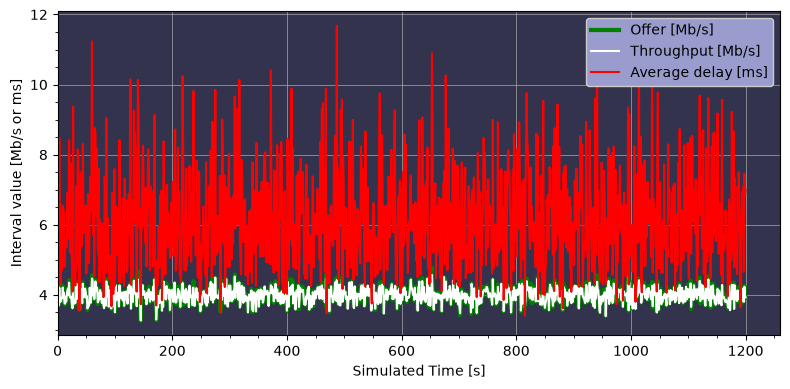

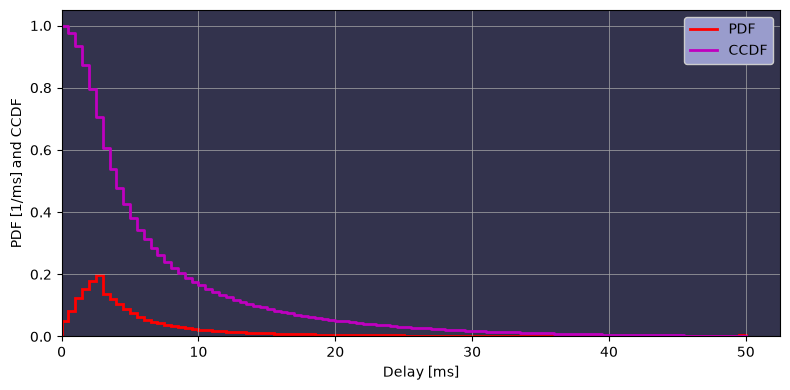

In [18]:
# --- Plot Total Results ---
offer = safe_read_csv(offer_file)
thrp = safe_read_csv(thrp_file)
delay = safe_read_csv(delay_file)

plot_thrp_offer_delay(offer, thrp, delay)
plot_delay_histogram(delay)
